In [ ]:
"""
CREDIT RISK ASSESSMENT - EDA & VISUALIZATION
Run this entire cell for complete analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 60)
print("CREDIT RISK ASSESSMENT - EDA & VISUALIZATION")
print("=" * 60)

# Load cleaned data
print("\n Loading cleaned data...")
df = pd.read_csv('C:/Users/AlexB/Desktop/credit_risk_assessment/data/processed/credit_data_cleaned.csv')
print(f" Cleaned data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Create reports folder
import os
os.makedirs('C:/Users/AlexB/Desktop/credit_risk_assessment/reports', exist_ok=True)

CREDIT RISK ASSESSMENT - EDA & VISUALIZATION

 Loading cleaned data...
 Cleaned data loaded: 149,391 rows, 11 columns


In [23]:
# ============================================
# 1. TARGET VARIABLE DISTRIBUTION
# ============================================

print("\n" + "=" * 60)
print("1. TARGET VARIABLE DISTRIBUTION")
print("=" * 60)

target_counts = df['SeriousDlqin2yrs'].value_counts()
target_percent = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print(f"\n0 = Good Credit (No Default):  {target_counts[0]:,} ({target_percent[0]:.2f}%)")
print(f"1 = Bad Credit (Default):    {target_counts[1]:,} ({target_percent[1]:.2f}%)")
print(f"\n Overall Default Rate: {df['SeriousDlqin2yrs'].mean():.2%}")


1. TARGET VARIABLE DISTRIBUTION

0 = Good Credit (No Default):  139,382 (93.30%)
1 = Bad Credit (Default):    10,009 (6.70%)

 Overall Default Rate: 6.70%


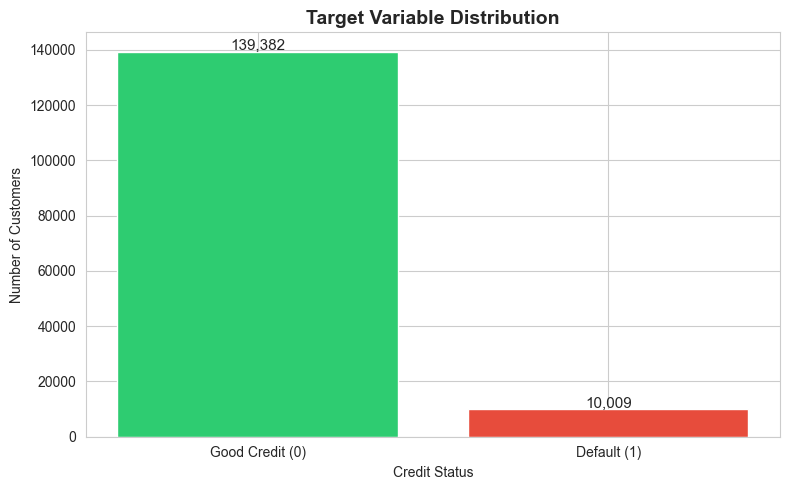

In [24]:
# Create bar chart
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Good Credit (0)', 'Default (1)'], target_counts.values, color=colors)
plt.title('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Credit Status')
plt.ylabel('Number of Customers')
for bar, val in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{val:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
# ============================================
# 2. CORRELATION ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("2. CORRELATION WITH TARGET")
print("=" * 60)

correlations = df.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print("\n Features most correlated with default risk:")
for feature, corr in correlations.items():
    print(f"   {feature:45} {corr:+.4f}")


2. CORRELATION WITH TARGET

 Features most correlated with default risk:
   SeriousDlqin2yrs                              +1.0000
   RevolvingUtilizationOfUnsecuredLines          +0.2793
   NumberOfTime30-59DaysPastDueNotWorse          +0.2233
   NumberOfTimes90DaysLate                       +0.2183
   NumberOfTime60-89DaysPastDueNotWorse          +0.1505
   NumberOfDependents                            +0.0465
   DebtRatio                                     -0.0177
   MonthlyIncome                                 -0.0178
   NumberRealEstateLoansOrLines                  -0.0205
   NumberOfOpenCreditLinesAndLoans               -0.0324
   age                                           -0.1157


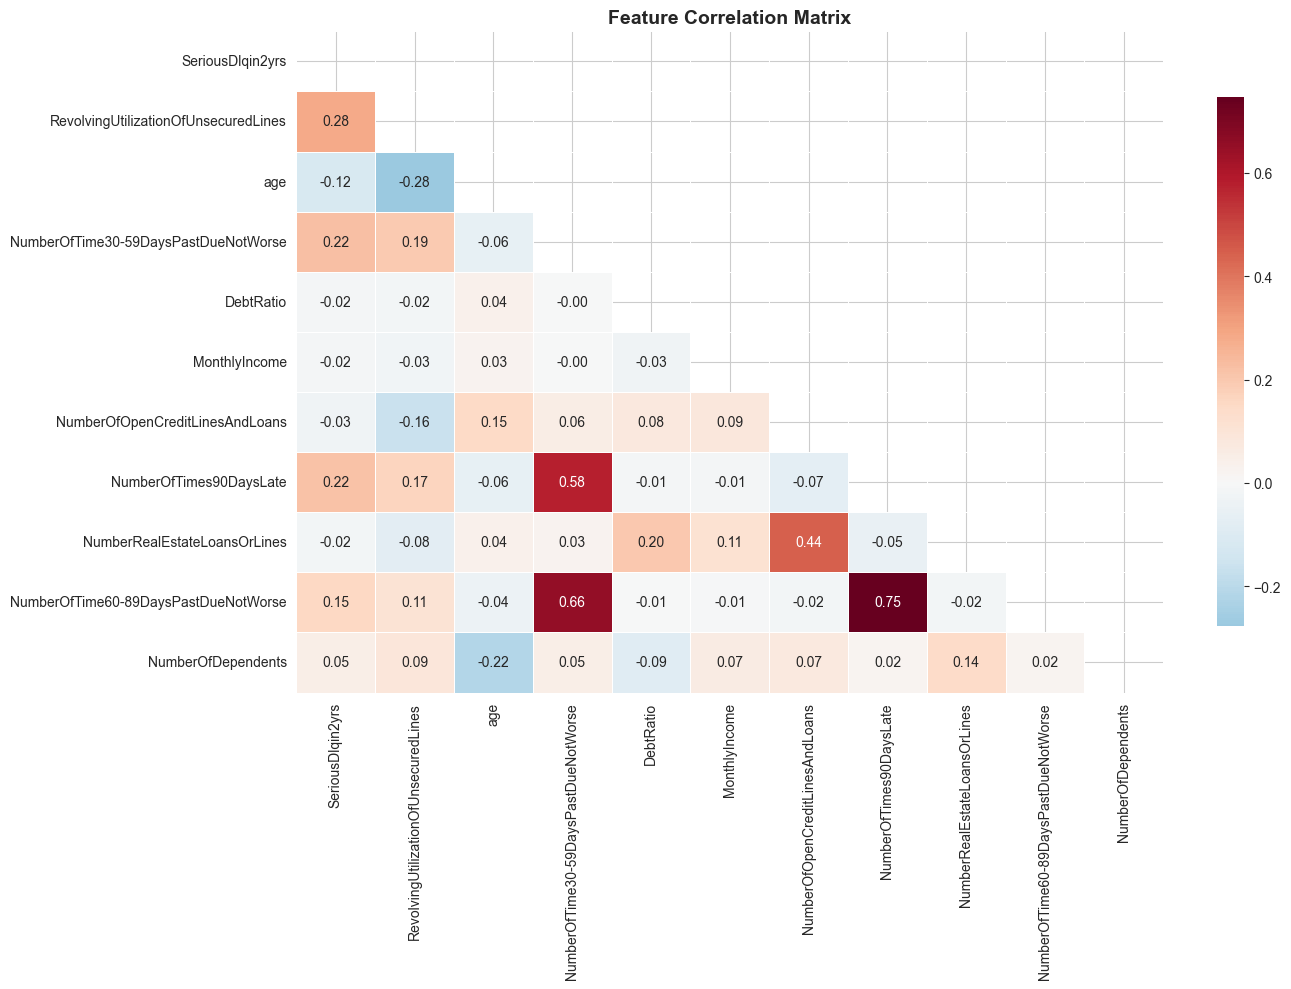

In [26]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


3. AGE ANALYSIS


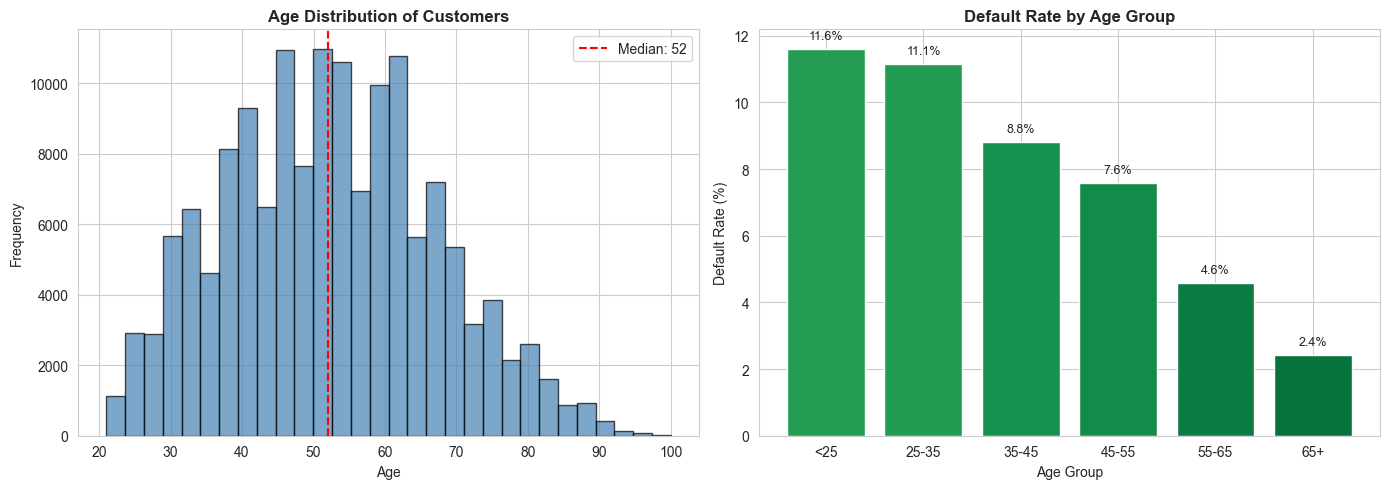

In [27]:
# ============================================
# 3. AGE ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("3. AGE ANALYSIS")
print("=" * 60)

# Create age groups
df['AgeGroup'] = pd.cut(df['age'], 
                         bins=[0, 25, 35, 45, 55, 65, 100],
                         labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])

# Default rate by age group
age_default = df.groupby('AgeGroup')['SeriousDlqin2yrs'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution of Customers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['age'].median(), color='red', linestyle='--', label=f'Median: {df["age"].median():.0f}')
axes[0].legend()

# Default rate by age group
colors = plt.cm.RdYlGn_r(age_default.values / 100)
bars = axes[1].bar(range(len(age_default)), age_default.values, color=colors)
axes[1].set_title('Default Rate by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(range(len(age_default)))
axes[1].set_xticklabels(age_default.index)

for bar, val in zip(bars, age_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
# plt.show()


4. CREDIT UTILIZATION ANALYSIS


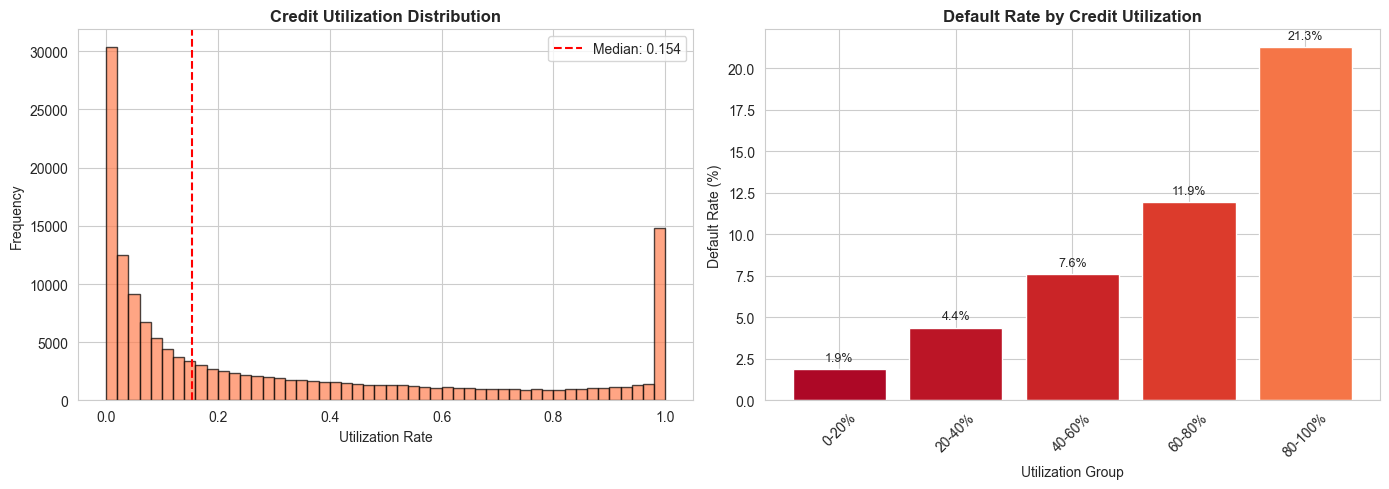


EDA & VISUALIZATION COMPLETE!

 EDA Summary:
   - Total records analyzed: 149,391
   - Default rate: 6.70%

 Key Findings:
   1. Age: Younger customers have higher default risk
   2. Credit Utilization: Strongest predictor of default
   3. Delinquency History: Past due = high future risk
   4. Income: Lower income = higher default rate

 Ready for Feature Engineering & Modeling!



In [28]:
# ============================================
# 4. CREDIT UTILIZATION ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("4. CREDIT UTILIZATION ANALYSIS")
print("=" * 60)

# Create utilization groups
df['UtilGroup'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], 
                          bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                          labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])

util_default = df.groupby('UtilGroup')['SeriousDlqin2yrs'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Utilization distribution
axes[0].hist(df['RevolvingUtilizationOfUnsecuredLines'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Credit Utilization Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['RevolvingUtilizationOfUnsecuredLines'].median(), color='red', linestyle='--', 
                label=f'Median: {df["RevolvingUtilizationOfUnsecuredLines"].median():.3f}')
axes[0].legend()

# Default rate by utilization group
colors = plt.cm.RdYlGn_r(1 - util_default.values / 100)
bars = axes[1].bar(range(len(util_default)), util_default.values, color=colors)
axes[1].set_title('Default Rate by Credit Utilization', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Utilization Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(range(len(util_default)))
axes[1].set_xticklabels(util_default.index, rotation=45)

for bar, val in zip(bars, util_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("EDA & VISUALIZATION COMPLETE!")
print("=" * 60)

print(f"""
 EDA Summary:
   - Total records analyzed: {len(df):,}
   - Default rate: {df['SeriousDlqin2yrs'].mean():.2%}
   
 Key Findings:
   1. Age: Younger customers have higher default risk
   2. Credit Utilization: Strongest predictor of default
   3. Delinquency History: Past due = high future risk
   4. Income: Lower income = higher default rate

 Ready for Feature Engineering & Modeling!
""")
